In [1]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'rock', 'peace']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

PATH = './gesture_dataset_sample'

I0000 00:00:1782142826.949229   58132 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782142829.640781   58132 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## helper function to load and parse annotations

In [2]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

## helper function to pre-process images (color channel conversion and resizing)

In [3]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [4]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

778
195
778
195


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [6]:
# Convert to float
X_train = np.array(X_train).astype('float32')
# Normalization [0,1]
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.


# Convert interger class labels in to one hot vector
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# rename for demonstration purposes
train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(778, 64, 64, 3) (195, 64, 64, 3) (778, 4) (195, 4)


In [7]:
# variables for hyperparameters
batch_size = 8 
epochs = 50 
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# Randomly disables 20% of neurons during each training step
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs

# If validation loss stops improving for 2 epochs, multiply  the learning rate by 0.2 (slow down/fine tune)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
# if validation loss doesn't improve for 3 epochs, stop training entierly
stop_early = EarlyStopping(monitor='val_loss', patience=3)

E0000 00:00:1782142857.044686   58132 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/blu/Studium/Master/3.Semester/ITT/Assignments/assignment-05-cnn-cato-droid/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## now, we can train the model using the fit() function
## this will take a while

In [8]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.2815 - loss: 1.3978 - val_accuracy: 0.3487 - val_loss: 1.3806 - learning_rate: 0.0010
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.3265 - loss: 1.3491 - val_accuracy: 0.4615 - val_loss: 1.1982 - learning_rate: 0.0010
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.5347 - loss: 1.0652 - val_accuracy: 0.7077 - val_loss: 0.7584 - learning_rate: 0.0010
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.6722 - loss: 0.7890 - val_accuracy: 0.7897 - val_loss: 0.6109 - learning_rate: 0.0010
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.7699 - loss: 0.6038 - val_accuracy: 0.8308 - val_loss: 0.5641 - learning_rate: 0.0010
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.8329 - loss: 0.4215 - val_accuracy: 0.8667 - val_loss: 0.4291 - learning_rate: 0.0010
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 175ms/step - accuracy: 0.8715 - loss: 0.

## saving the model

the function will create a directory for your model and save structure and weights in there

sometimes you will see the .h5 format being used - even though this is a bit faster and needs less space, it comes with its limitations and isn't used that much any more

In [9]:
model.save('gesture_recognition.keras')

# and this is how you load the model
# model = keras.models.load_model("gesture_recognition.keras")

## Make predictions for Cato and Tutor images

  0%|          | 0/4 [00:00<?, ?it/s]

'annot-cato'


  0%|          | 0/7 [00:00<?, ?it/s]

'annot-tutors'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
before [[1.53867656e-03 9.98457849e-01 2.56201110e-06 8.73967792e-07]
 [5.79065783e-03 8.45364869e-01 1.93508323e-02 1.29493564e-01]
 [4.69877012e-03 4.16433126e-01 5.09352908e-02 5.27932823e-01]
 [1.82898420e-05 4.40867208e-02 9.52075720e-01 3.81922652e-03]
 [6.39591526e-05 8.83147266e-07 1.05287923e-04 9.99829948e-01]
 [1.10209280e-13 9.99999940e-01 6.40213887e-15 1.24040825e-19]
 [9.20924425e-01 2.83784214e-02 1.85987749e-03 4.88373078e-02]
 [6.08564035e-13 9.99999940e-01 1.64744119e-12 1.49090438e-16]
 [7.07216614e-08 7.73731972e-06 4.26523298e-01 5.73468924e-01]
 [1.20640581e-10 1.00000000e+00 8.98678325e-15 1.29980415e-17]
 [1.00000000e+00 3.98112827e-11 8.14884325e-18 1.14119434e-13]
 [1.68981514e-13 1.00000000e+00 7.26592909e-15 1.09073886e-18]
 [9.63006616e-01 4.40453785e-03 1.74880903e-02 1.51008591e-02]
 [9.92543070e-13 1.00000000e+00 1.69253533e-12 1.17700257e-16]]
probabilities [1 1 3 2 3 1 0 1 3 1 0 1 0 1]


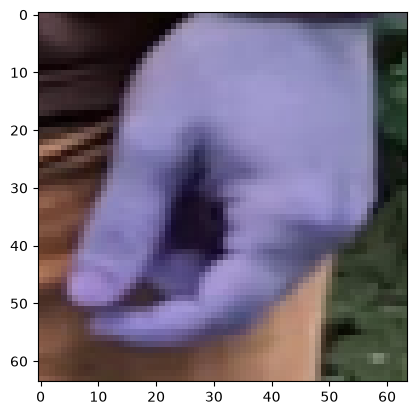

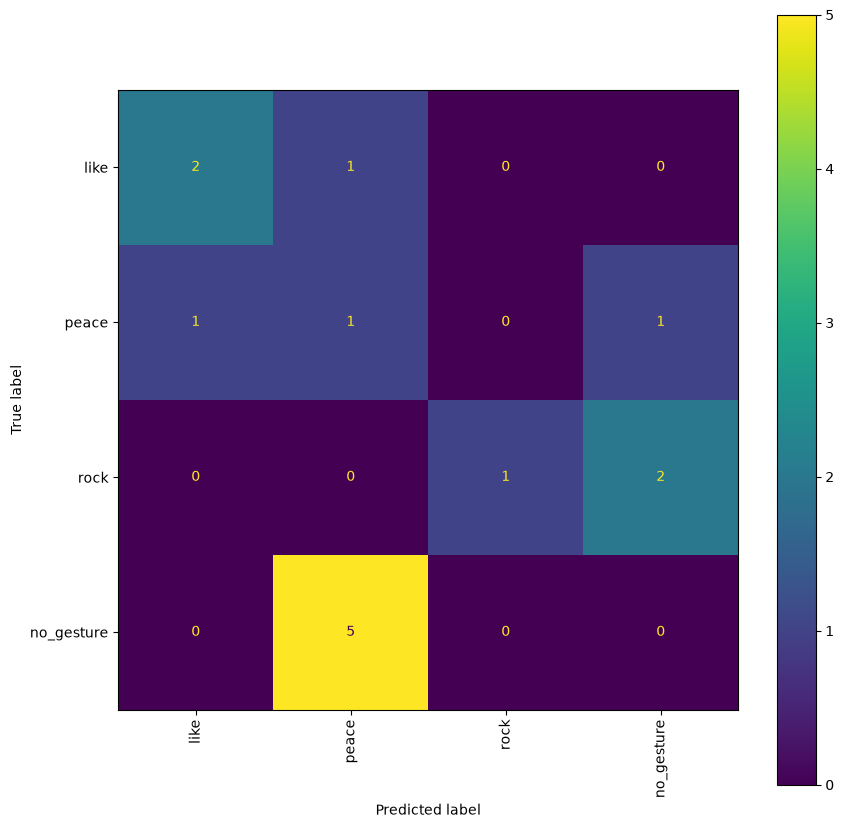

In [ ]:
annotations = dict()
names = ["cato", "tutor"]

with open('./cato_images/annot-cato.json') as f:
        annotations["cato"] = json.load(f)
with open('./tutor_images/annot-tutors.json') as f:
        annotations["tutor"] = json.load(f)


def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)

# loop over all names
# loop over all files in the name's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for name in names:
    for filename in tqdm(os.listdir(f'./{name}_images')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'./{name}_images/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[name][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            label = annotation['labels'][i]
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

            #show last preprocessed image
            plt.imshow(preprocessed)

# Convert to float
images = np.array(images).astype('float32')
# Normalization [0,1]
images = images / 255.

# let the model make predictions for our data
y_predictions = model.predict(images)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(labels, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

#FIXME it seems to work, but the predictions are very bad?